# Example use-case: Cosmological gravitational-wave merger rate density

The original project this codebase was designed for was to calculate the cosmological binary black-hole (BHBH) gravitational-wave merger and supernova transient rate density ([Hendriks et al. 2023](https://doi.org/10.1093/mnras/stad2857)).
 
The following section will flesh out the steps to perform a similar calculation.

Several ingredients are necessary here:
- population-synthesis results that contain BHBH systems
- A cosmological star formation rate density

This convolution is an event-based convolution by integration.

In [1]:
import os
import json
import pkg_resources
import copy
import logging
import h5py
import pandas as pd
import numpy as np
import astropy.units as u

from syntheticstellarpopconvolve import convolve
from syntheticstellarpopconvolve import default_convolution_config
from syntheticstellarpopconvolve.general_functions import temp_dir

TMP_DIR = temp_dir("notebooks", "notebook_example_GW_merger_rate_density", clean_path=True)
VERBOSITY = 0

# The flag below allows the user to run this notebook without the full data or starformation rate. 
FULL_VERSION = os.getenv("EXAMPLE_USECASE_GW_FULL_VERSION", False)

Lets start with loading some data and see which metallicities are present. This data is generated by a grid-based population-synthesis evolution at a series of fixed metallicities.

This package contains a minimized version of the data for this usecase, but if the environment variable `EXAMPLE_DATA_USECASE_GW_FILENAME` points to the full dataset it will use that.

In [2]:
data_filename = os.getenv('EXAMPLE_DATA_USECASE_GW_FILENAME') if FULL_VERSION else None
example_usecase_GW_events_filename = data_filename if data_filename is not None else pkg_resources.resource_filename(
    "syntheticstellarpopconvolve",
    "example_data/example_data_usecase_gw.h5"
)
example_usecase_GW_events_data = pd.read_hdf(example_usecase_GW_events_filename,  key='data/combined_dataframes')
if data_filename is not None:
    example_usecase_GW_events_data['delay_time_values_in_years'] = example_usecase_GW_events_data['formation_time_values_in_years']+example_usecase_GW_events_data['merger_time_values_in_years']
example_usecase_GW_events_data=example_usecase_GW_events_data.query('stellar_type_1==14 & stellar_type_2==14')
example_usecase_GW_events_data=example_usecase_GW_events_data.query('comenv_counter==0')

#
print(example_usecase_GW_events_data.columns)
log10_metallicity_centers = np.log10(example_usecase_GW_events_data['metallicity'].unique())
print(log10_metallicity_centers)
stepsize = np.diff(log10_metallicity_centers)
log10_bin_edges = np.concatenate([log10_metallicity_centers[:-1]-stepsize/2, log10_metallicity_centers[-2:]+stepsize[:2]/2])

Index(['uuid', 'mass_1', 'zams_mass_1', 'mass_2', 'zams_mass_2',
       'stellar_type_1', 'stellar_type_2', 'metallicity', 'eccentricity',
       'period', 'zams_period', 'fallback_1', 'fallback_2', 'random_seed',
       'undergone_ppisn_1', 'undergone_ppisn_2', 'comenv_counter',
       'stable_rlof_counter', 'undergone_CE_with_HG_donor',
       'undergone_CE_with_MS_donor', 'formation_time_values_in_years',
       'merger_time_values_in_years', 'number_per_solar_mass_values',
       'local_index', 'delay_time_values_in_years'],
      dtype='object')
[-1.85454545 -2.08181818 -2.30909091 -2.53636364 -2.76363636 -2.99090909
 -3.21818182 -3.44545455 -3.67272727 -3.9       ]


Next up is to set up the star formation info. In this example we use a redshift-based cosmological starformation history, and an accompanying metallicity distribution, both described in [van Son et al. 2023](https://dx.doi.org/10.3847/1538-4357/acbf51). 

The metallicity distribution of [van Son et al. 2023](https://dx.doi.org/10.3847/1538-4357/acbf51) is defined in log Z, and thus we will need to either convert it to a different base, or provide our input metallicity values in log Z as well.

We will first display a high resolution version of this metallicity-dependent star formation rate history, and then configure it to our needs.

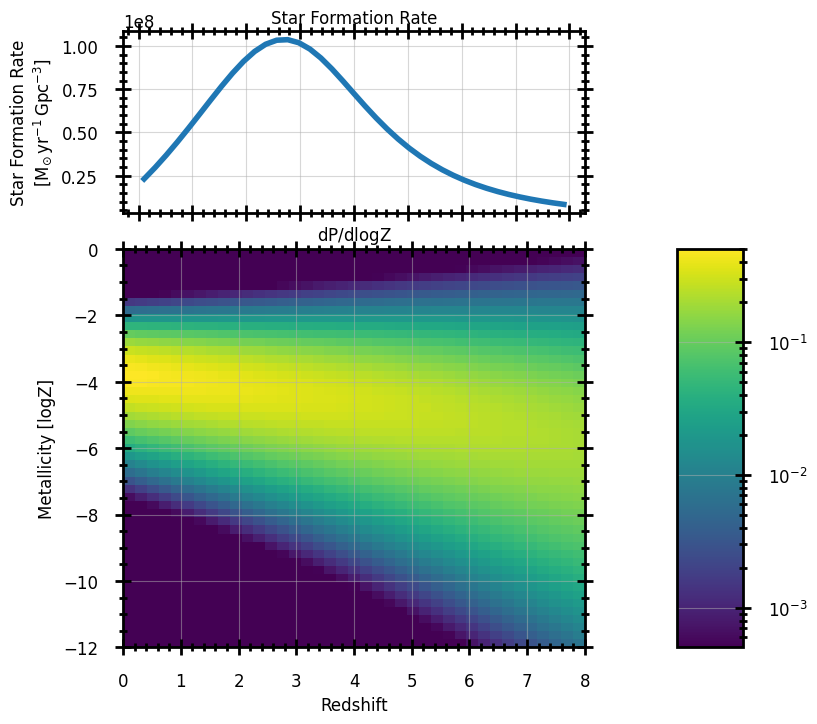

In [5]:
import matplotlib as plt
from syntheticstellarpopconvolve.starformation_rate_distributions import starformation_rate_distribution_vanSon2023
from syntheticstellarpopconvolve.metallicity_distributions import metallicity_distribution_vanSon2022
from syntheticstellarpopconvolve.general_functions import calculate_bincenters, calculate_bin_edges
from syntheticstellarpopconvolve.SFR_dict_plotting_routines import plot_sfr_dict

# Set up redshift bin info
num_redshift_bins = 40
redshift_bin_edges = np.linspace(0, 8, num_redshift_bins); redshift_bin_centers = calculate_bincenters(redshift_bin_edges)

# Set up metallicity bin info
num_metallicity_bins = 50
log_metallicity_bin_edges = np.linspace(-12, 0, num_metallicity_bins); log_metallicity_bin_centers = calculate_bincenters(log_metallicity_bin_edges)

#
sfr = starformation_rate_distribution_vanSon2023(redshift_bin_centers).to(u.Msun/u.yr/u.Gpc**3)

#
dpdlogZ = metallicity_distribution_vanSon2022(
    log_metallicity_centers=log_metallicity_bin_centers,
    redshifts=redshift_bin_centers,
)

high_res_sfr_dict = {
    "redshift_bin_edges": redshift_bin_edges,
    "starformation_rate_array": sfr,
    "metallicity_bin_edges": log_metallicity_bin_edges,
    "metallicity_distribution_array": dpdlogZ,
}

axis_dict = plot_sfr_dict(
    high_res_sfr_dict,
    time_type="redshift",
    metallicity_string="logZ",
    metallicity_distribution_multiply_by_metallicity_bin_sizes=False,
    metallicity_distribution_multiply_by_sfr=False,
    metallicity_distribution_scale="log10",
    metallicity_distribution_cmap=copy.copy(plt.cm.viridis),
    return_axis_dict=True,
    figsize=(8,8),
    fontsize=12,
)

That looks good! Now lets set up our actual SFR dict and lets make sure that the metallicities in our dataset are expressed in log as well. We will let the (log) metallicity values of our data determine the metallicity bin values.

(-12.0, 0.0)

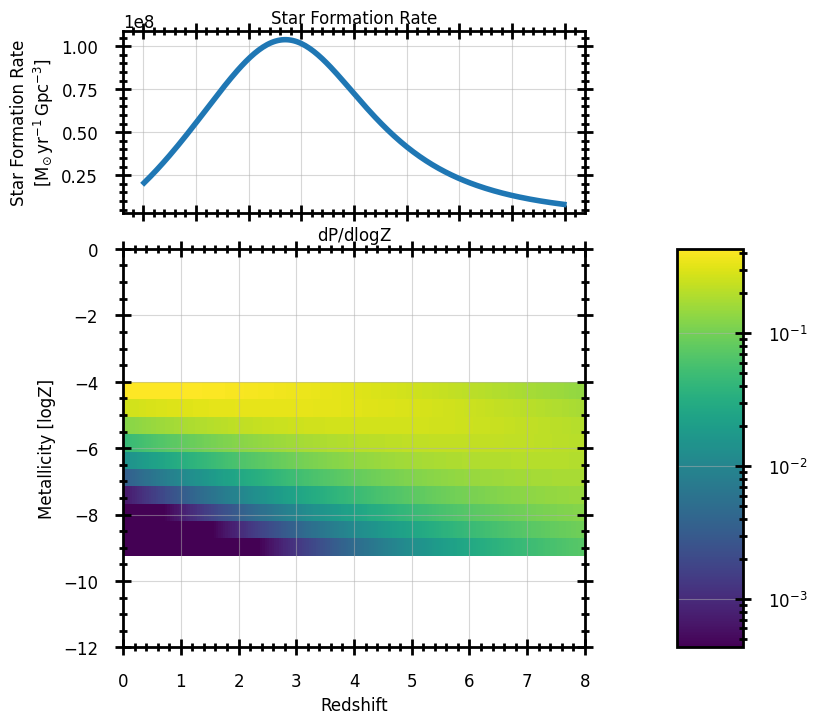

In [4]:
example_usecase_GW_events_data['log_metallicity'] = np.log(example_usecase_GW_events_data['metallicity'])

log_metallicity_bin_centers = np.sort(example_usecase_GW_events_data['log_metallicity'].unique())
log_metallicity_bin_edges = calculate_bin_edges(log_metallicity_bin_centers)

# Set up redshift bin info
redshift_bin_edges = np.linspace(0, 8, 200); redshift_bin_centers = calculate_bincenters(redshift_bin_edges)

#
sfr = starformation_rate_distribution_vanSon2023(redshift_bin_centers).to(u.Msun/u.yr/u.Gpc**3)

#
dpdlogZ = metallicity_distribution_vanSon2022(
    log_metallicity_centers=log_metallicity_bin_centers,
    redshifts=redshift_bin_centers,
)

sfr_dict = {
    "redshift_bin_edges": redshift_bin_edges,
    "starformation_rate_array": sfr,
    "metallicity_bin_edges": log_metallicity_bin_edges,
    "metallicity_distribution_array": dpdlogZ,  # We need to transpose!
}

axis_dict = plot_sfr_dict(
    sfr_dict,
    time_type="redshift",
    metallicity_string="logZ",
    metallicity_distribution_multiply_by_metallicity_bin_sizes=False,
    metallicity_distribution_multiply_by_sfr=False,
    metallicity_distribution_scale="log10",
    metallicity_distribution_cmap=copy.copy(plt.cm.viridis),
    return_axis_dict=True,
    figsize=(8,8),
    fontsize=12,
)
axis_dict['ax_mssfr'].set_ylim([-12, 0])

Now that we have set up the star formation information and loaded the input data, we can combine everything into the convolution config

In [5]:
# Assign filenames
input_hdf5_filename = os.path.join(TMP_DIR, "input_hdf5.h5")
output_hdf5_filename = os.path.join(TMP_DIR, "output_hdf5.h5")

# Open input file
input_hdf5_file = h5py.File(input_hdf5_filename, "w")

# Create groups main
input_hdf5_file.create_group("input_data")
input_hdf5_file.create_group("config")

# add group for events
input_hdf5_file.create_group("input_data/events")

# close
input_hdf5_file.close()

# store the data frame in the hdf5file
example_usecase_GW_events_data.to_hdf(input_hdf5_filename, key="input_data/events/example_GW_merger_rate_density")

# Some general configuration
convolution_config = copy.copy(default_convolution_config)
convolution_config['logger'].setLevel(logging.WARNING)
convolution_config["input_filename"] = input_hdf5_filename
convolution_config["output_filename"] = output_hdf5_filename
convolution_config["tmp_dir"] = TMP_DIR
convolution_config["redshift_interpolator_data_output_filename"] = os.path.join(
    TMP_DIR, "interpolator_dict.p"
)
convolution_config["multiply_by_time_binsize"] = False

# convolution instructions
convolution_config["convolution_instructions"] = [
    {
        "convolution_type": "integrate",
        "input_data_name": "example_GW_merger_rate_density",
        "output_data_name": "intrinsic",
        "ignore_metallicity": False,
        "data_column_dict": {
            # required
            "normalized_yield": "number_per_solar_mass_values",
            "delay_time": {"column_name": "delay_time_values_in_years", "unit": u.yr},
        },
    },
]

#
convolution_config["time_type"] = "redshift"

# configure the target convolution times. In this case we only want to model the rate at redshift ~0, so its a simple set up
convolution_config["convolution_redshift_bin_edges"] = np.array([0, 0.25])

# store
convolution_config["SFR_info"] = sfr_dict

In [6]:
# convolve
convolve(config=convolution_config)

[convolve_events.py:39 - convolve_events_by_integration_post_convolution_hook_wrapper ] 2025-01-19 18:26:10,883: Handling post-convolution function hook call for convolve-events by integration
[convolve_populations.py:113 - store_convolution_result_entries ] 2025-01-19 18:26:10,904: Storing yield


## Readout and plotting

In [7]:
import json
import matplotlib.pyplot as plt

# we are interested in the primary mass distribution. lets extract the primary mass values:
example_usecase_GW_events_data['primary_mass'] = example_usecase_GW_events_data[['mass_1', 'mass_2']].max(axis=1)
print(example_usecase_GW_events_data['primary_mass'])
primary_mass_array = example_usecase_GW_events_data['primary_mass'].to_numpy()

# read out content and integrate until today
with h5py.File(convolution_config["output_filename"], "r") as output_hdf5_file:

    # print(output_hdf5_file.keys())
    # print(output_hdf5_file["output_data"].keys())
    # print(output_hdf5_file["output_data/event"].keys())
    # print(output_hdf5_file["output_data/event/example_GW_merger_rate_density"].keys())
    # print(output_hdf5_file["output_data/event/example_GW_merger_rate_density/intrinsic"].keys())
    # print(
    #     output_hdf5_file["output_data/event/example_GW_merger_rate_density/intrinsic/convolution_results"].keys()
    # )
    # print(
    #     output_hdf5_file["output_data/event/example_GW_merger_rate_density/intrinsic/convolution_results/0.125"].keys()
    # )

    key = "output_data/event/example_GW_merger_rate_density/intrinsic/convolution_results/0.125/"
    
    # 
    yield_data = output_hdf5_file[key+'yield'][()]

    # convert units
    unit_dict = json.loads(
        output_hdf5_file[key].attrs["units"]
    )
    unit_dict = {key: u.Unit(val) for key, val in unit_dict.items()}

local_index
40968.013978     11.9689
61191.013978     11.4592
61319.013978     11.6551
123888.013978    11.9358
123895.013978    11.9358
                  ...   
829466.000126    53.0586
829475.000126    53.0309
831491.000126    35.6917
831825.000126    21.1335
832097.000126    22.6061
Name: primary_mass, Length: 33201, dtype: float64


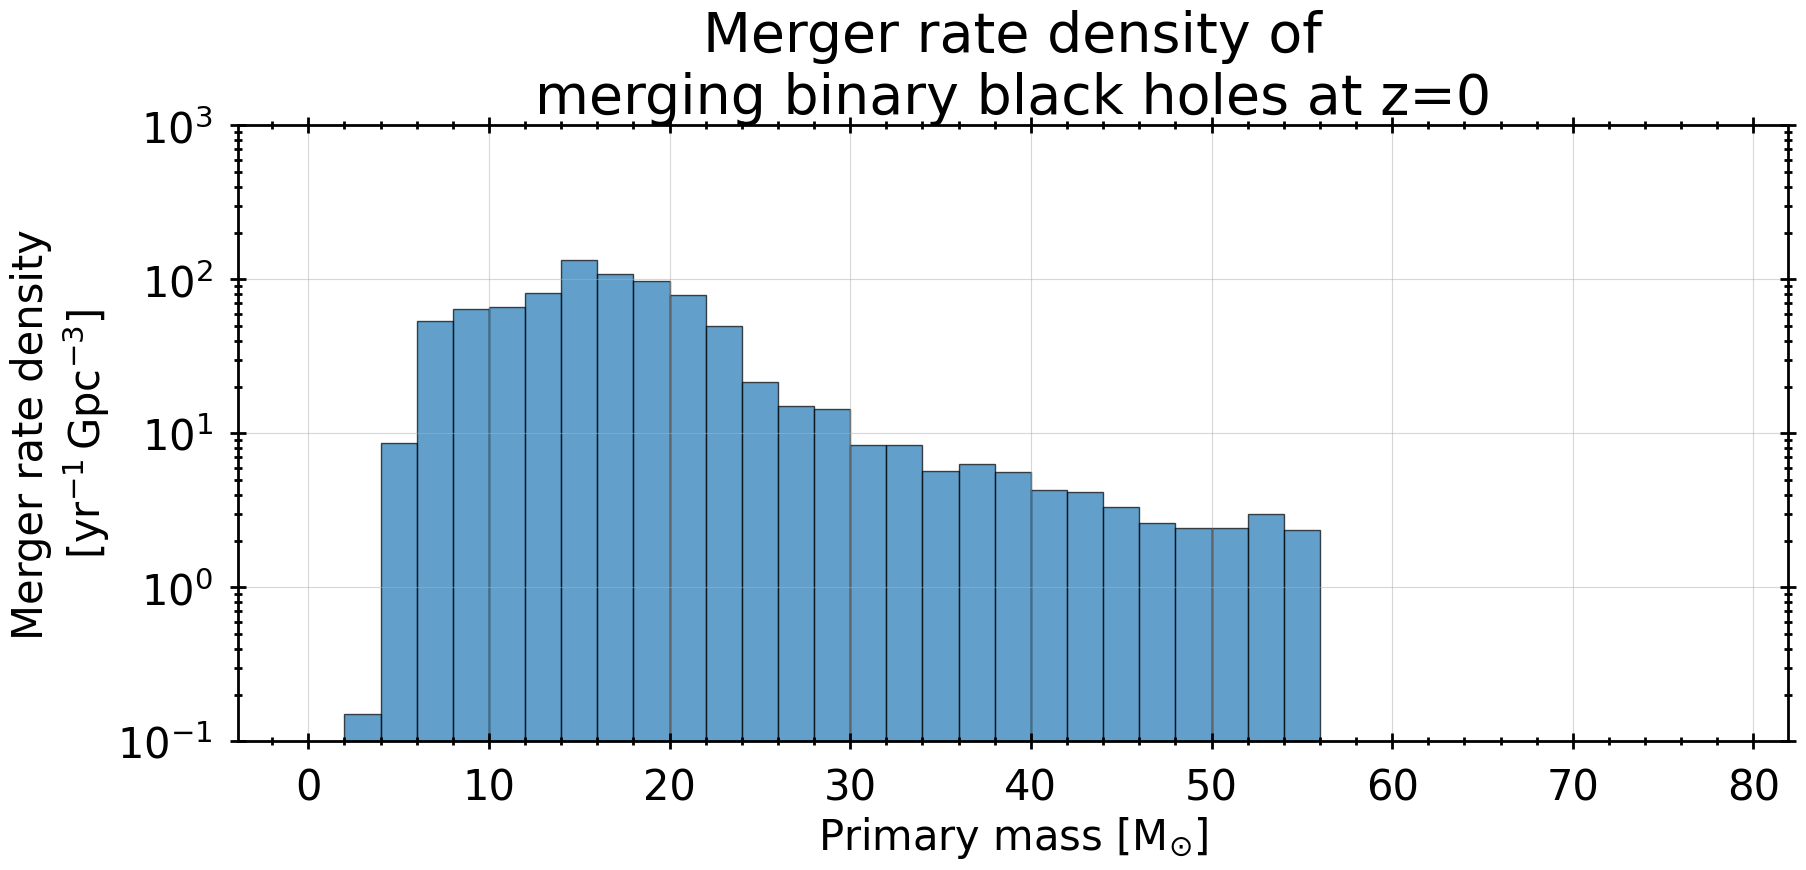

In [8]:
primary_mass_bins = np.arange(0, 80, 2)



#
fig, ax = plt.subplots(figsize=(20,8))

# Compute weighted histogram
ax.hist(primary_mass_array, bins=primary_mass_bins, weights=yield_data, edgecolor='black', alpha=0.7)

# Set axis labels and title
ax.set_xlabel('Primary mass [{}]'.format(u.Msun.to_string("latex_inline")))
ax.set_ylabel('Merger rate density\n[{}]'.format(unit_dict['yield'].to_string("latex_inline")))
ax.set_title('Merger rate density of\nmerging binary black holes at z=0')
ax.set_ylim(0.1, 1000)
ax.set_yscale('log')

plt.show()

With the full datasets for .. availble on https://zenodo.org/records/8083112, and a better resolved convolution, we can recreate the following figures